In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [2]:
dp_df = pd.read_csv('dp_parent_results.csv', low_memory=False)
print(f'All: {len(dp_df)}')
dp_candidates = dp_df[(dp_df['p_value'] < 0.05) & (dp_df['delta_dv'] > 75)]
print(f'DP Candidates: {len(dp_candidates)} ({len(dp_candidates) / len(dp_df) * 100:.2f}%)')

All: 61905
DP Candidates: 26116 (42.19%)


In [ ]:
with open('dp_candidates_ids.txt', 'w+') as f:
    for tid in dp_candidates['TARGETID'].to_list():
        f.write(f"{tid}\n")

In [4]:
display(dp_candidates.head(5))

,TARGETID,p_value,dv,delta_dv,sigma,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
2,39627739380056564,0.000047,"(np.float64(54.23557963405434), np.float64(-77...",131.450450,"(np.float64(50.13363863752554), np.float64(31....",False,False,False,False,False,...,3,1,-1,-1,-1,4,0,2,-1,-1
3,39627739380056768,0.045512,"(np.float64(3.6917048319503856), np.float64(-1...",134.377466,"(np.float64(44.611683053915876), np.float64(0....",False,False,False,False,False,...,3,1,4,-1,-1,7,0,2,5,6
6,39627739380057506,0.000199,"(np.float64(120.70568266484035), np.float64(-5...",178.091228,"(np.float64(39.7098954588015), np.float64(73.0...",False,False,False,False,False,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
12,39627739380058467,0.010212,"(np.float64(87.7901619504298), np.float64(-28....",116.295175,"(np.float64(30.665694298712733), np.float64(51...",False,False,False,False,False,...,3,1,4,-1,-1,7,0,2,5,6
14,39627739380060210,0.000026,"(np.float64(76.57122211976792), np.float64(-90...",167.101261,"(np.float64(52.71544344441726), np.float64(54....",False,False,False,False,False,...,-1,-1,-1,-1,-1,2,0,1,-1,-1


In [ ]:
dp_candidates.to_csv('dp_candidates.csv', index=False)

OII3726: 1623
OII3729: 2745
Hbeta: 4882
OIII4959: 303
OIII5007: 1789
NII6548: 2067
Halpha: 21476
NII6583: 14437
SII6716: 5776
SII6731: 3228


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_86019/3596865704.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp_candidates[col] = dp_candidates[col].fillna(False)


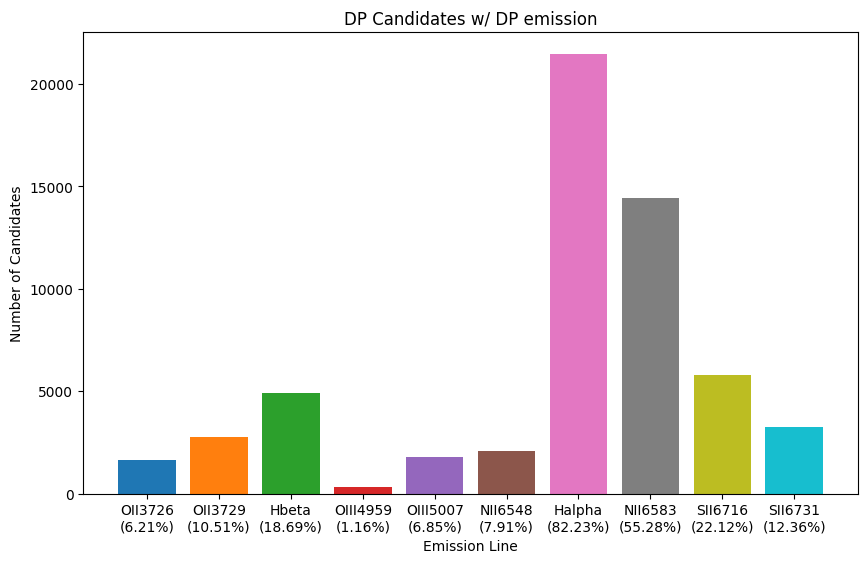

In [6]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
plt.figure(figsize=(10, 6))
for col in dp_cols:
    dp_candidates[col] = dp_candidates[col].fillna(False)
    print(f"{col[:-3]}: {np.sum(dp_candidates[col])}")
    plt.bar(col[:-3]+f'\n({np.sum(dp_candidates[col]) / len(dp_candidates):.2%})', np.sum(dp_candidates[col]))
plt.xlabel("Emission Line")
plt.ylabel("Number of Candidates")
plt.title("DP Candidates w/ DP emission")
# plt.savefig("./figures/Jan2/dp_candidates_emission.png")
plt.show()

In [7]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
rank_cols = [col[:-3]+'_rank' for col in dp_cols]

dp_counts = dp_candidates[dp_cols].sum(axis=1)
dp_candidates['dp_count'] = dp_counts
display(dp_candidates[['TARGETID', 'dp_count']+dp_cols+rank_cols].head(5))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_86019/3729606561.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp_candidates['dp_count'] = dp_counts


,TARGETID,dp_count,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
2,39627739380056564,2,False,False,False,False,False,False,True,True,...,3,1,-1,-1,-1,4,0,2,-1,-1
3,39627739380056768,0,False,False,False,False,False,False,False,False,...,3,1,4,-1,-1,7,0,2,5,6
6,39627739380057506,1,False,False,False,False,False,False,True,False,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
12,39627739380058467,3,False,False,False,False,False,False,True,True,...,3,1,4,-1,-1,7,0,2,5,6
14,39627739380060210,2,False,False,False,False,False,False,True,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1


In [8]:
dp_ = dp_candidates[dp_cols]
display(dp_.head(10))

,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
2,False,False,False,False,False,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,True,False,False,False
12,False,False,False,False,False,False,True,True,True,False
14,False,False,False,False,False,False,True,True,False,False
18,False,True,False,False,False,True,True,True,True,True
19,False,False,False,False,False,False,True,True,False,False
22,False,False,False,False,False,False,True,False,False,False
24,False,False,False,False,False,False,True,True,False,False
25,False,False,False,False,False,True,True,True,True,True


In [9]:
rank_ = dp_candidates[rank_cols]
display(rank_.head(10))

,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
2,3,1,-1,-1,-1,4,0,2,-1,-1
3,3,1,4,-1,-1,7,0,2,5,6
6,-1,-1,-1,-1,-1,2,0,1,-1,-1
12,3,1,4,-1,-1,7,0,2,5,6
14,-1,-1,-1,-1,-1,2,0,1,-1,-1
18,3,2,-1,-1,-1,5,0,1,4,6
19,3,2,-1,-1,-1,6,0,1,4,5
22,-1,-1,-1,-1,-1,2,0,1,-1,-1
24,-1,-1,2,-1,-1,3,0,1,-1,-1
25,4,2,3,9,8,7,0,1,5,6


In [10]:
def get_actual_dp_count(row):
    """
    Calculates the number of consecutive double peaks starting from the brightest emission line.
    - Filters out lines with a rank of -1 (not detected).
    - Sorts the remaining emission lines by rank (brightness).
    - If the brightest line does not have a double peak, returns 0.
    - Otherwise, counts consecutive lines with double peaks starting from the brightest and returns the count.
    """
    # Create a list of (rank, dp_status) tuples for detected lines (rank != -1)
    line_info = []
    for rank_col, dp_col in zip(rank_cols, dp_cols):
        rank = row[rank_col]
        if rank != -1:
            line_info.append((rank, row[dp_col]))
    
    # If no lines were detected, there are no DPs to count.
    if not line_info:
        return 0
        
    # Sort by rank (the first element of the tuple)
    line_info.sort()

    # Check if the brightest line (first in the sorted list) has a double peak
    if not line_info[0][1]:
        return 0

    # Count consecutive double peaks from the brightest
    actual_dp_count = 0
    for rank, has_dp in line_info:
        if has_dp:
            actual_dp_count += 1
        else:
            # Stop counting when a line without a double peak is found
            break
            
    return actual_dp_count

# Apply the function to each row to create the new column
dp_candidates['actual_dp_count'] = dp_candidates.apply(get_actual_dp_count, axis=1)

# Display the head of the DataFrame with the new column
display(dp_candidates[['TARGETID', 'dp_count', 'actual_dp_count']].head(10))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_86019/1668467894.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp_candidates['actual_dp_count'] = dp_candidates.apply(get_actual_dp_count, axis=1)


,TARGETID,dp_count,actual_dp_count
2,39627739380056564,2,1
3,39627739380056768,0,0
6,39627739380057506,1,1
12,39627739380058467,3,1
14,39627739380060210,2,2
18,39627739380061198,6,3
19,39627739380062010,2,2
22,39627739384251743,1,1
24,39627739384252917,2,2
25,39627739384253125,5,2


In [11]:
dp_sample = dp_candidates[dp_candidates['actual_dp_count'] != False & (dp_candidates['actual_dp_count'] > 0)]
print(len(dp_sample))


21454


In [12]:
display(dp_sample[['TARGETID', 'dp_count', 'actual_dp_count']+dp_cols+rank_cols].head(10))

,TARGETID,dp_count,actual_dp_count,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
2,39627739380056564,2,1,False,False,False,False,False,False,True,...,3,1,-1,-1,-1,4,0,2,-1,-1
6,39627739380057506,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
12,39627739380058467,3,1,False,False,False,False,False,False,True,...,3,1,4,-1,-1,7,0,2,5,6
14,39627739380060210,2,2,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
18,39627739380061198,6,3,False,True,False,False,False,True,True,...,3,2,-1,-1,-1,5,0,1,4,6
19,39627739380062010,2,2,False,False,False,False,False,False,True,...,3,2,-1,-1,-1,6,0,1,4,5
22,39627739384251743,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
24,39627739384252917,2,2,False,False,False,False,False,False,True,...,-1,-1,2,-1,-1,3,0,1,-1,-1
25,39627739384253125,5,2,False,False,False,False,False,True,True,...,4,2,3,9,8,7,0,1,5,6
27,39627739384253866,2,1,False,False,False,False,False,False,True,...,-1,-1,1,-1,-1,4,0,2,3,5


In [13]:
counts = dp_sample['actual_dp_count'].value_counts().sort_index()
summary_df = counts.reindex(range(1, 11), fill_value=0).reset_index()
summary_df.columns = ['Number of actual double peaks', 'Number of DP Samples']
display(summary_df)

,Number of actual double peaks,Number of DP Samples
0,1,9813
1,2,7873
2,3,1664
3,4,605
4,5,250
5,6,270
6,7,214
7,8,353
8,9,324
9,10,88


In [ ]:
with open('dp_samples_ids.txt', 'w+') as f:
    for tid in dp_sample['TARGETID'].to_list():
        f.write(f"{tid}\n")

In [ ]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=read_ids('dp_samples_ids.txt'))

In [16]:
display(SPECTRA.df[['TARGETID','LOGSFR', 'LOGM']].head(10))

,TARGETID,LOGSFR,LOGM
0,39627739380056564,0.941032,10.452706
1,39627739380057506,-0.880754,10.324258
2,39627739380058467,1.031611,10.402426
3,39627739380060210,0.039087,10.496312
4,39627739380061198,0.903058,9.514435
5,39627739380062010,0.143419,10.082529
6,39627739384251743,0.461850,9.779942
7,39627739384252917,-1.504955,10.019834
8,39627739384253125,0.054528,9.603887
9,39627739384253866,1.160900,10.556721


In [17]:
dp_sample['LOGSFR'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_sample['LOGM'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGM'])
display(dp_sample[['TARGETID', 'LOGSFR', 'LOGM']].head(10))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_86019/1808280438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp_sample['LOGSFR'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGSFR'])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_86019/1808280438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp_sample['LOGM'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGM'])


,TARGETID,LOGSFR,LOGM
2,39627739380056564,0.941032,10.452706
6,39627739380057506,-0.880754,10.324258
12,39627739380058467,1.031611,10.402426
14,39627739380060210,0.039087,10.496312
18,39627739380061198,0.903058,9.514435
19,39627739380062010,0.143419,10.082529
22,39627739384251743,0.461850,9.779942
24,39627739384252917,-1.504955,10.019834
25,39627739384253125,0.054528,9.603887
27,39627739384253866,1.160900,10.556721


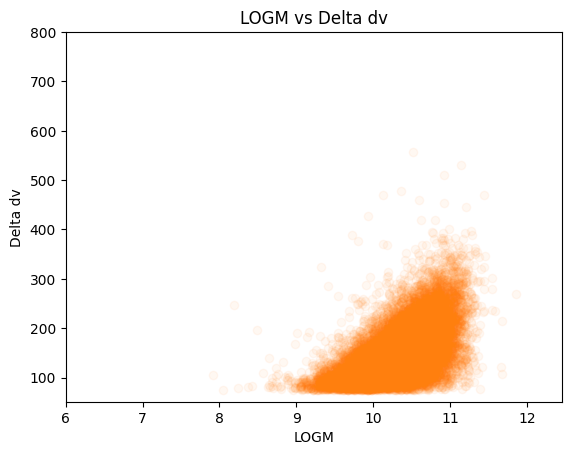

In [18]:
plt.scatter(dp_sample['LOGM'], dp_sample['delta_dv'], alpha=0.05, color='C1')
plt.xlabel('LOGM')
plt.ylabel('Delta dv')
plt.title('LOGM vs Delta dv')
plt.xlim(left=6)
plt.ylim(top=800)
# plt.savefig('./figures/Jan2/LOGM_vs_Delta_dv_dp_samples.png')
plt.show()

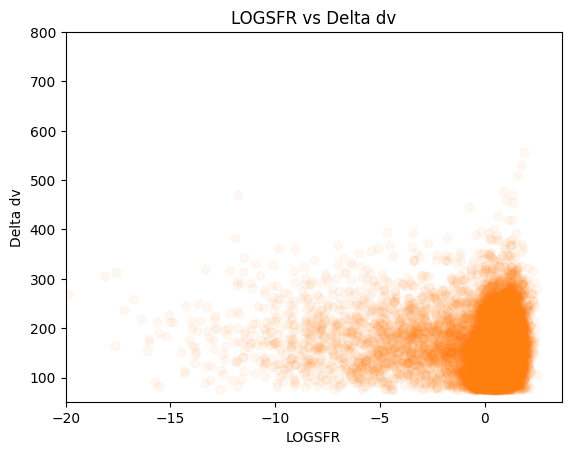

In [19]:
plt.scatter(dp_sample['LOGSFR'], dp_sample['delta_dv'], alpha=0.05, color='C1')
plt.xlabel('LOGSFR')
plt.ylabel('Delta dv')
plt.title('LOGSFR vs Delta dv')
plt.xlim(left=-20)
plt.ylim(top=800)
# plt.savefig('./figures/Jan2/LOGSFR_vs_Delta_dv_dp_samples.png')
plt.show()

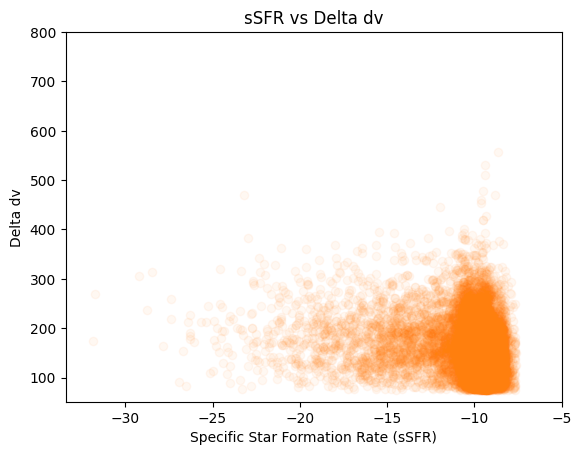

In [20]:
plt.scatter(dp_sample['LOGSFR']-dp_sample['LOGM'], dp_sample['delta_dv'], alpha=0.05, color='C1')
plt.xlabel('Specific Star Formation Rate (sSFR)')
plt.ylabel('Delta dv')
plt.title('sSFR vs Delta dv')
plt.xlim(right=-5)
plt.ylim(top=800)
# plt.savefig('./figures/Jan2/LOGSFR_vs_Delta_dv_dp_samples.png')
plt.show()

In [21]:
dp_sample.to_csv('dp_samples.csv', index=False)